In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from src.data_loader import get_con

con = get_con()
print("Connected to DuckDB")

Connected to DuckDB


In [2]:
# Check all three e-Stat tables
for table in ["estat_cpi", "estat_retail_pref", "estat_retail_industry"]:
    n = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    cols = con.execute(f"DESCRIBE {table}").df()["column_name"].tolist()
    print(f"\n{table}: {n:,} rows")
    print(f"Columns: {cols}")
    print(con.execute(f"SELECT * FROM {table} LIMIT 3").df().to_string())


estat_cpi: 4,294 rows
Columns: ['date', 'year', 'month', 'item_code', 'area', 'cpi_value']
        date  year  month item_code   area  cpi_value
0 1970-01-01  1970      1      0003  00000       32.9
1 1970-01-01  1970      1      0002  00000       28.2
2 1970-01-01  1970      1      0004  00000       41.7

estat_retail_pref: 8,761 rows
Columns: ['year', 'area_code', 'industry_code', 'tab', 'unit', 'value']
   year area_code industry_code       tab                      unit      value
0  2021     00000             I  701-2021  number of establishments  1022230.0
1  2021     0009A             I  701-2021  number of establishments   306589.0
2  2021     0019A             I  701-2021  number of establishments   624715.0

estat_retail_industry: 676 rows
Columns: ['year', 'area_code', 'industry_code', 'tab', 'value']
   year area_code industry_code  tab   value
0  2023     00000            00  011  867767
1  2023     00000            01  011  311857
2  2023     00000          0101  011    1

In [3]:
# What item codes do we have?
cpi_items = con.execute("""
    SELECT item_code, 
           COUNT(*) AS records,
           MIN(date) AS earliest,
           MAX(date) AS latest,
           AVG(cpi_value) AS avg_cpi
    FROM estat_cpi
    GROUP BY item_code
    ORDER BY records DESC
""").df()

print(f"Unique item codes: {cpi_items['item_code'].nunique()}")
print(cpi_items.to_string(index=False))

Unique item codes: 7
item_code  records   earliest     latest    avg_cpi
     0001      674 1970-01-01 2026-02-01  86.132344
     0003      674 1970-01-01 2026-02-01  90.378190
     0004      674 1970-01-01 2026-02-01 101.049852
     0002      674 1970-01-01 2026-02-01  81.218694
     1001      614 1975-01-01 2026-02-01 108.235342
     1002      610 1975-01-01 2026-02-01 106.697049
     0005      374 1995-01-01 2026-02-01  95.930481


In [4]:
# Fetch item code metadata from e-Stat API
import requests
import os
from dotenv import load_dotenv
load_dotenv()

APP_ID = os.getenv("ESTAT_APP_ID")
ESTAT_BASE = "https://api.e-stat.go.jp/rest/3.0/app/json"

r = requests.get(
    f"{ESTAT_BASE}/getStatsData",
    params={
        "appId":       APP_ID,
        "lang":        "E",
        "statsDataId": "0003427113",
        "limit":       "1",
        "metaGetFlg":  "Y"
    },
    timeout=15
)

raw = r.json()
class_objs = (raw.get("GET_STATS_DATA", {})
                 .get("STATISTICAL_DATA", {})
                 .get("CLASS_INF", {})
                 .get("CLASS_OBJ", []))

if isinstance(class_objs, dict):
    class_objs = [class_objs]

for obj in class_objs:
    print(f"\nDimension: {obj.get('@id')} — {obj.get('@name')}")
    classes = obj.get("CLASS", [])
    if isinstance(classes, dict):
        classes = [classes]
    for c in classes[:10]:
        print(f"  {c.get('@code')}: {c.get('@name')}")


Dimension: tab — Tabulated variable
  1: Index
  2: Change from the previous period (year, fiscal year, or month)
  3: Change over the year

Dimension: cat01 — Items(2020-base)
  0001: All items
  0002: Food
  0003: Cereals
  0004: Rice
  1001: Non-glutinous rice-A
  1002: Non-glutinous rice-B
  0005: Bread
  1021: White bread
  1022: Bean-jam buns
  1023: Curry buns

Dimension: area — Area(2020-base)
  13A01: Ku-area of Tokyo
  00000: All Japan
  00012: Major cities
  00013: Middle cities
  00018: Small cities A
  00021: Small cities B, towns and villages
  00042: Hokkaido districts
  00043: Tohoku districts
  00044: Kanto districts
  00049: Hokuriku districts

Dimension: time — Time
  2026000303: Mar. 2026
  2026000202: Feb. 2026
  2026000101: Jan. 2026
  2025100000: 2025
  2025001212: Dec. 2025
  2025001111: Nov. 2025
  2025001010: Oct. 2025
  2025000909: Sep. 2025
  2025000808: Aug. 2025
  2025000707: Jul. 2025


In [5]:
cpi = con.execute("SELECT * FROM estat_cpi").df()
cpi["date"] = pd.to_datetime(cpi["date"])

# Map item codes to names
item_names = {
    "0001": "All items",
    "0002": "Food",
    "0003": "Cereals",
    "0004": "Rice",
    "0005": "Bread",
    "1001": "Non-glutinous rice-A",
    "1002": "Non-glutinous rice-B"
}
cpi["item_name"] = cpi["item_code"].map(item_names)

# Keep only Japan total (area=00000), index values (tab would be in raw)
# Our data already filtered to area 00000 during fetch
# Focus on post-2015 for modern analysis
cpi_modern = cpi[cpi["date"] >= "2015-01-01"].copy()

print(f"Modern CPI records (2015+): {len(cpi_modern):,}")
print(f"Date range: {cpi_modern['date'].min().date()} → {cpi_modern['date'].max().date()}")
print(f"\nItems available:")
print(cpi_modern.groupby(["item_code","item_name"])["cpi_value"]
      .agg(["count","mean"]).round(2))

Modern CPI records (2015+): 938
Date range: 2015-01-01 → 2026-02-01

Items available:
                                count    mean
item_code item_name                          
0001      All items               134  102.20
0002      Food                    134  104.50
0003      Cereals                 134  106.99
0004      Rice                    134  109.53
0005      Bread                   134  106.52
1001      Non-glutinous rice-A    134  109.67
1002      Non-glutinous rice-B    134  109.29


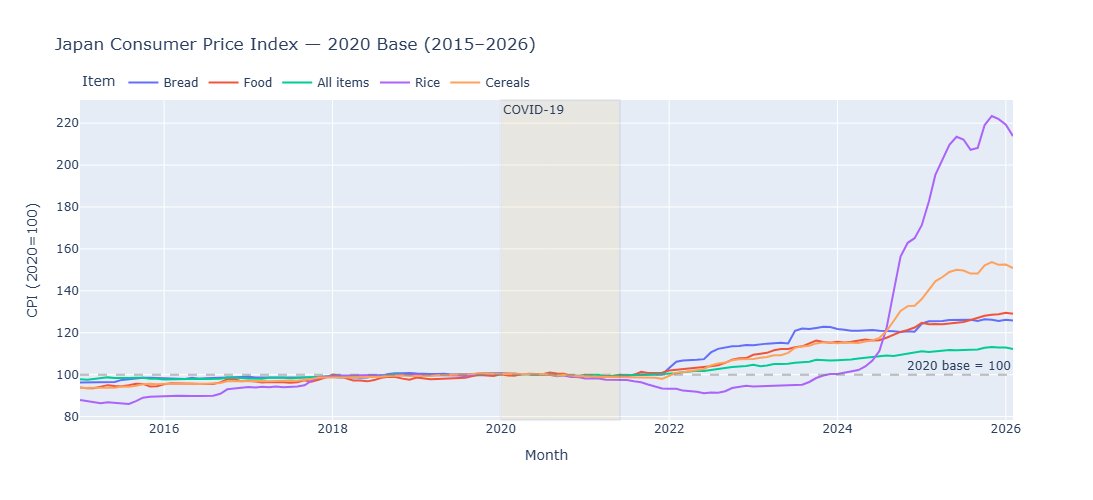

In [6]:
# Focus on key items for clean chart
key_items = ["All items", "Food", "Cereals", "Rice", "Bread"]
cpi_plot = cpi_modern[cpi_modern["item_name"].isin(key_items)]

fig1 = px.line(
    cpi_plot,
    x="date",
    y="cpi_value",
    color="item_name",
    title="Japan Consumer Price Index — 2020 Base (2015–2026)",
    labels={"cpi_value": "CPI (2020=100)",
            "date":      "Month",
            "item_name": "Item"}
)

# Add reference line at 100 (2020 base)
fig1.add_hline(
    y=100, line_dash="dash",
    line_color="gray", opacity=0.5,
    annotation_text="2020 base = 100"
)

# Shade COVID period
fig1.add_vrect(
    x0="2020-01-01", x1="2021-06-01",
    fillcolor="orange", opacity=0.08,
    annotation_text="COVID-19",
    annotation_position="top left"
)

fig1.update_layout(height=500,
    legend=dict(orientation="h", y=1.1))
fig1.show()

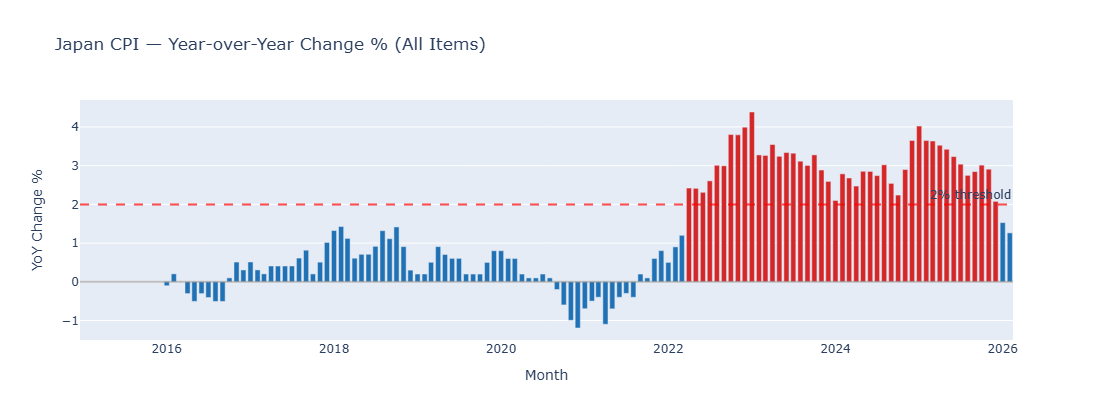

Avg YoY inflation 2022-2026: 2.86%
Peak inflation: 4.39% (Jan 2023)


In [7]:
# Calculate YoY change for All items
cpi_all = cpi_modern[cpi_modern["item_name"] == "All items"].copy()
cpi_all = cpi_all.sort_values("date")
cpi_all["yoy_change"] = cpi_all["cpi_value"].pct_change(12) * 100

fig2 = go.Figure()

colors = ["#d62728" if v > 2 else "#2171b5"
          for v in cpi_all["yoy_change"].fillna(0)]

fig2.add_trace(go.Bar(
    x=cpi_all["date"],
    y=cpi_all["yoy_change"],
    marker_color=colors,
    name="YoY inflation %"
))

fig2.add_hline(
    y=2, line_dash="dash", line_color="red",
    annotation_text="2% threshold",
    opacity=0.7
)

fig2.add_hline(y=0, line_color="gray", opacity=0.5)

fig2.update_layout(
    title="Japan CPI — Year-over-Year Change % (All Items)",
    xaxis_title="Month",
    yaxis_title="YoY Change %",
    height=420
)
fig2.show()

# Key stats
post2022 = cpi_all[cpi_all["date"] >= "2022-01-01"]
print(f"Avg YoY inflation 2022-2026: {post2022['yoy_change'].mean():.2f}%")
print(f"Peak inflation: {cpi_all['yoy_change'].max():.2f}% "
      f"({cpi_all.loc[cpi_all['yoy_change'].idxmax(), 'date'].strftime('%b %Y')})")

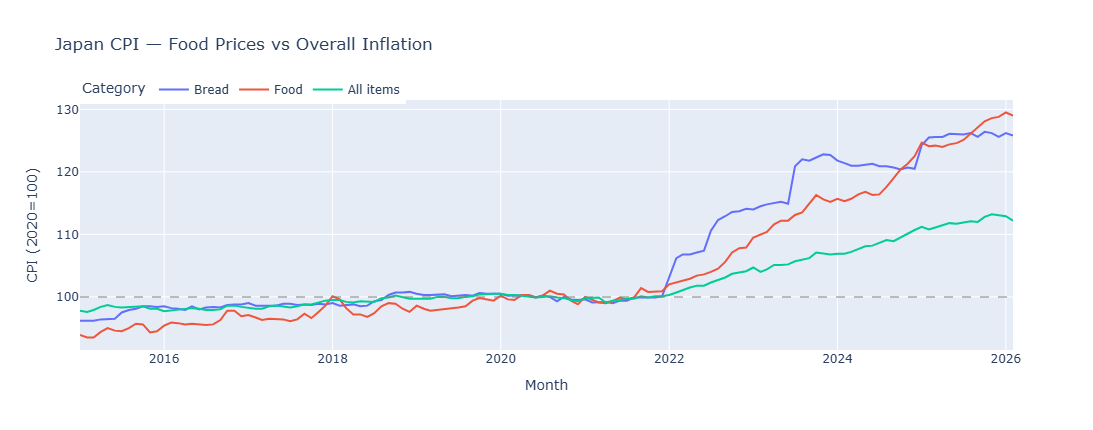

In [8]:
cpi_compare = cpi_modern[
    cpi_modern["item_name"].isin(["All items", "Food", "Bread"])
].copy()

fig3 = px.line(
    cpi_compare,
    x="date",
    y="cpi_value",
    color="item_name",
    title="Japan CPI — Food Prices vs Overall Inflation",
    labels={"cpi_value": "CPI (2020=100)",
            "date":      "Month",
            "item_name": "Category"}
)

fig3.add_hline(y=100, line_dash="dash",
               line_color="gray", opacity=0.5)

fig3.update_layout(height=430,
    legend=dict(orientation="h", y=1.1))
fig3.show()

In [9]:
retail_ind = con.execute("SELECT * FROM estat_retail_industry").df()

print(f"Industry records: {len(retail_ind):,}")
print(f"Years: {retail_ind['year'].unique()}")
print(f"Tab codes: {retail_ind['tab'].unique()}")
print(f"\nTop industry codes:")
print(retail_ind.groupby(["year","industry_code"])["value"]
      .sum().reset_index()
      .sort_values("value", ascending=False)
      .head(10).to_string(index=False))

Industry records: 676
Years: [2023 2024]
Tab codes: <ArrowStringArray>
['011', '022', '0221', '0222']
Length: 4, dtype: str

Top industry codes:
 year industry_code      value
 2024            00 1250276712
 2023            00 1205170817
 2024            01  949034563
 2023            01  914370543
 2024            02  301242140
 2023            02  290800276
 2023          0104  266363059
 2024          0104  265574487
 2024          0105  265009868
 2023          0105  248330066


In [10]:
r2 = requests.get(
    f"{ESTAT_BASE}/getStatsData",
    params={
        "appId":       APP_ID,
        "lang":        "E",
        "statsDataId": "0004021940",
        "limit":       "1",
        "metaGetFlg":  "Y"
    },
    timeout=15
)

raw2 = r2.json()
class_objs2 = (raw2.get("GET_STATS_DATA", {})
                   .get("STATISTICAL_DATA", {})
                   .get("CLASS_INF", {})
                   .get("CLASS_OBJ", []))

if isinstance(class_objs2, dict):
    class_objs2 = [class_objs2]

for obj in class_objs2:
    print(f"\nDimension: {obj.get('@id')} — {obj.get('@name')}")
    classes = obj.get("CLASS", [])
    if isinstance(classes, dict):
        classes = [classes]
    for c in classes:
        print(f"  {c.get('@code')}: {c.get('@name')}")


Dimension: tab — Tabulated variable
  011: Number of establishments
  022: Annual sales of goods
  0221: Annual sales of goods (wholesale)
  0222: Annual sales of goods (retail trade)

Dimension: cat01 — Industry of establishment
  00: I Wholesale and Retail Trade
  01: I1 Wholesale Trade
  0101: 50 Wholesale trade, general merchandise
  010101: 501 Wholesale trade, general merchandise
  01010101: 50A Wholesale trade, general merchandise (with 100 or more employees)
  01010102: 50B Miscellaneous wholesale trade, general merchandise
  0102: 51 Wholesale trade (textile and apparel)
  010201: 511 Textile products (except apparel, apparel accessories and notions)
  010202: 512 Apparel
  010203: 513 Apparel accessories and notions
  0103: 52 Wholesale trade (food and beverages)
  010301: 521 Agricultural, livestock and aquatic products
  01030101: 52A Rice, barley and other cereals
  01030102: 52B Vegetables and fruits
  01030103: 52C Meat and poultry
  01030104: 52D Fresh fish and shellfi

In [11]:
# Map top-level industry codes to readable names
industry_map = {
    "00":   "Wholesale & Retail (Total)",
    "01":   "Wholesale Trade",
    "0101": "General Merchandise Wholesale",
    "0102": "Textile & Apparel Wholesale",
    "0103": "Food & Beverage Wholesale",
    "0104": "Building Materials Wholesale",
    "0105": "Machinery & Equipment Wholesale",
    "0106": "Miscellaneous Wholesale",
    "02":   "Retail Trade",
    "0207": "General Merchandise Retail",
    "0208": "Apparel Retail",
    "0209": "Food & Beverage Retail",
    "0210": "Machinery & Equipment Retail",
    "0211": "Miscellaneous Retail",
    "0212": "Nonstore Retailers",
}

tab_map = {
    "011":  "Establishments",
    "022":  "Annual Sales (Total)",
    "0221": "Annual Sales (Wholesale)",
    "0222": "Annual Sales (Retail)",
}

retail_ind["industry_name"] = retail_ind["industry_code"].map(industry_map)
retail_ind["tab_name"]      = retail_ind["tab"].map(tab_map)

# Keep only top-level codes with labels
retail_clean = retail_ind[
    retail_ind["industry_name"].notna()
].copy()

print(f"Labelled records: {len(retail_clean):,}")
print(retail_clean[["year","industry_name","tab_name","value"]]
      .sort_values(["year","tab_name"])
      .head(20).to_string(index=False))

Labelled records: 120
 year                   industry_name              tab_name     value
 2023      Wholesale & Retail (Total) Annual Sales (Retail) 145677971
 2023                 Wholesale Trade Annual Sales (Retail)   2548683
 2023   General Merchandise Wholesale Annual Sales (Retail)      5491
 2023     Textile & Apparel Wholesale Annual Sales (Retail)    208587
 2023       Food & Beverage Wholesale Annual Sales (Retail)    581540
 2023    Building Materials Wholesale Annual Sales (Retail)    519820
 2023 Machinery & Equipment Wholesale Annual Sales (Retail)    812478
 2023         Miscellaneous Wholesale Annual Sales (Retail)    419444
 2023                    Retail Trade Annual Sales (Retail) 143129288
 2023      General Merchandise Retail Annual Sales (Retail)   9158892
 2023                  Apparel Retail Annual Sales (Retail)   8712811
 2023          Food & Beverage Retail Annual Sales (Retail)  37758203
 2023    Machinery & Equipment Retail Annual Sales (Retail)  2940812

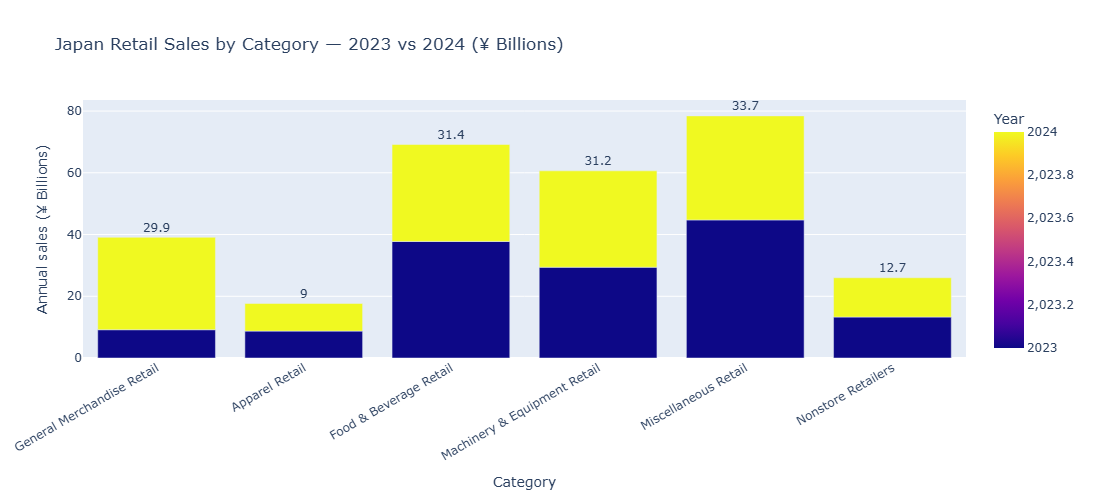

In [12]:
# Focus on retail trade sub-categories, annual sales total
retail_cats = retail_clean[
    (retail_clean["tab_name"] == "Annual Sales (Retail)") &
    (retail_clean["industry_code"].isin(
        ["0207","0208","0209","0210","0211","0212"]
    ))
].copy()

retail_cats["value_bn"] = (retail_cats["value"] / 1_000_000).round(2)

fig4 = px.bar(
    retail_cats,
    x="industry_name",
    y="value_bn",
    color="year",
    barmode="group",
    text=retail_cats["value_bn"].round(1),
    title="Japan Retail Sales by Category — 2023 vs 2024 (¥ Billions)",
    labels={"value_bn":      "Annual sales (¥ Billions)",
            "industry_name": "Category",
            "year":          "Year"},
    color_discrete_map={2023: "#6baed6", 2024: "#08519c"}
)
fig4.update_traces(textposition="outside")
fig4.update_layout(
    height=500,
    xaxis_tickangle=-30,
    legend=dict(orientation="h", y=1.1)
)
fig4.show()

YoY growth by retail category:
                    category  sales_2023  sales_2024  yoy_growth_pct
        Miscellaneous Retail  44726823.0  33701065.0          -24.65
      Food & Beverage Retail  37758203.0  31423231.0          -16.78
          Nonstore Retailers  13266058.0  12719035.0           -4.12
              Apparel Retail   8712811.0   8958717.0            2.82
Machinery & Equipment Retail  29408123.0  31223063.0            6.17
  General Merchandise Retail   9158892.0  29935297.0          226.84


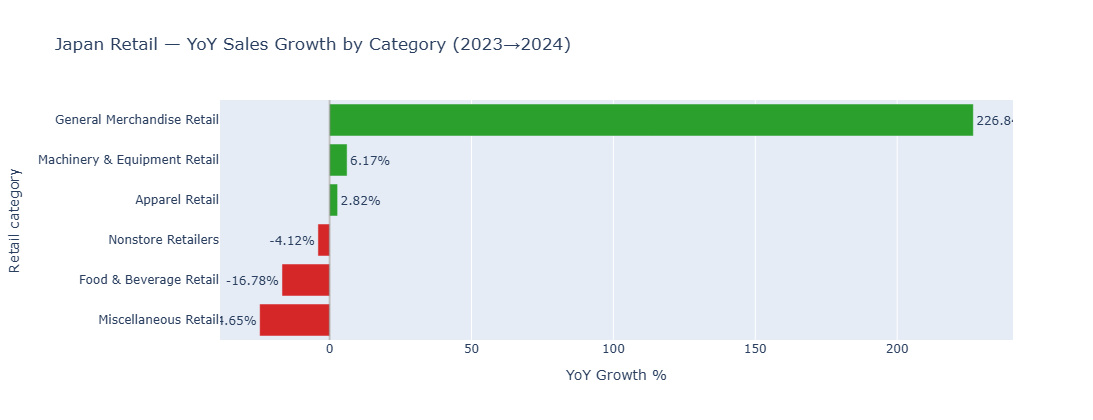

In [13]:
# Pivot to calculate YoY growth
retail_pivot = retail_cats.pivot_table(
    index="industry_name",
    columns="year",
    values="value"
).reset_index()

retail_pivot.columns = ["category", "sales_2023", "sales_2024"]
retail_pivot["yoy_growth_pct"] = (
    (retail_pivot["sales_2024"] - retail_pivot["sales_2023"]) /
    retail_pivot["sales_2023"] * 100
).round(2)

retail_pivot = retail_pivot.sort_values("yoy_growth_pct", ascending=True)

print("YoY growth by retail category:")
print(retail_pivot[["category","sales_2023","sales_2024","yoy_growth_pct"]]
      .to_string(index=False))

colors = ["#2ca02c" if v > 0 else "#d62728"
          for v in retail_pivot["yoy_growth_pct"]]

fig5 = px.bar(
    retail_pivot,
    x="yoy_growth_pct",
    y="category",
    orientation="h",
    text=retail_pivot["yoy_growth_pct"].astype(str) + "%",
    title="Japan Retail — YoY Sales Growth by Category (2023→2024)",
    labels={"yoy_growth_pct": "YoY Growth %",
            "category":       "Retail category"}
)
fig5.update_traces(
    textposition="outside",
    marker_color=colors
)
fig5.add_vline(x=0, line_color="gray", opacity=0.5)
fig5.update_layout(height=420, margin=dict(l=220))
fig5.show()

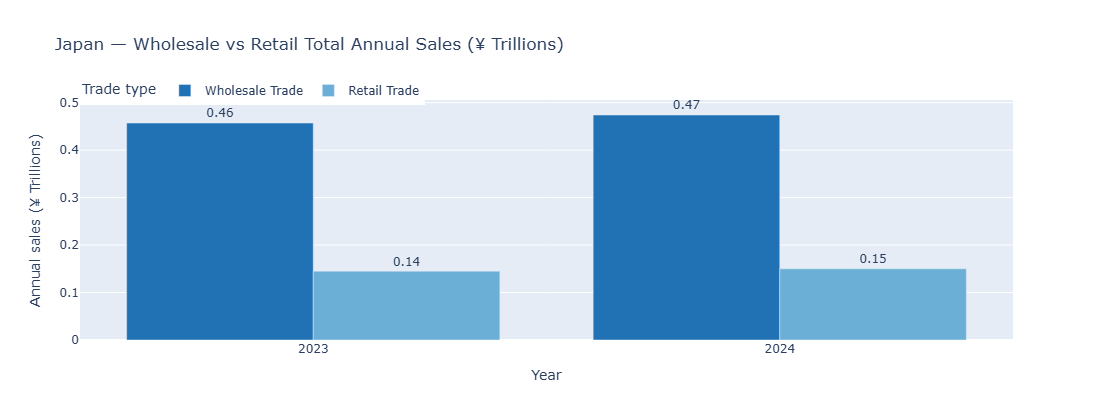

In [14]:
# Total wholesale vs retail 2023 and 2024
wvsr = retail_clean[
    (retail_clean["industry_code"].isin(["01","02"])) &
    (retail_clean["tab_name"] == "Annual Sales (Total)")
].copy()

wvsr["value_tn"] = (wvsr["value"] / 1_000_000_000).round(3)

fig6 = px.bar(
    wvsr,
    x="year",
    y="value_tn",
    color="industry_name",
    barmode="group",
    text=wvsr["value_tn"].round(2),
    title="Japan — Wholesale vs Retail Total Annual Sales (¥ Trillions)",
    labels={"value_tn":      "Annual sales (¥ Trillions)",
            "industry_name": "Trade type",
            "year":          "Year"},
    color_discrete_map={
        "Wholesale Trade": "#2171b5",
        "Retail Trade":    "#6baed6"
    }
)
fig6.update_traces(textposition="outside")
fig6.update_layout(height=420,
    legend=dict(orientation="h", y=1.1))
fig6.show()

In [18]:
retail_pref = con.execute("SELECT * FROM estat_retail_pref").df()

# Prefecture totals: 5-char codes ending in 000
# e.g. 01000=Hokkaido, 13000=Tokyo, 27000=Osaka
pref_totals = retail_pref[
    (retail_pref["area_code"].str.len() == 5) &
    (retail_pref["area_code"].str.endswith("000")) &
    (retail_pref["area_code"] != "00000")
].copy()

# Map prefecture codes to names
pref_names = {
    "01000": "Hokkaido",  "02000": "Aomori",    "03000": "Iwate",
    "04000": "Miyagi",    "05000": "Akita",      "06000": "Yamagata",
    "07000": "Fukushima", "08000": "Ibaraki",    "09000": "Tochigi",
    "10000": "Gunma",     "11000": "Saitama",    "12000": "Chiba",
    "13000": "Tokyo",     "14000": "Kanagawa",   "15000": "Niigata",
    "16000": "Toyama",    "17000": "Ishikawa",   "18000": "Fukui",
    "19000": "Yamanashi", "20000": "Nagano",     "21000": "Gifu",
    "22000": "Shizuoka",  "23000": "Aichi",      "24000": "Mie",
    "25000": "Shiga",     "26000": "Kyoto",      "27000": "Osaka",
    "28000": "Hyogo",     "29000": "Nara",       "30000": "Wakayama",
    "31000": "Tottori",   "32000": "Shimane",    "33000": "Okayama",
    "34000": "Hiroshima", "35000": "Yamaguchi",  "36000": "Tokushima",
    "37000": "Kagawa",    "38000": "Ehime",      "39000": "Kochi",
    "40000": "Fukuoka",   "41000": "Saga",       "42000": "Nagasaki",
    "43000": "Kumamoto",  "44000": "Oita",       "45000": "Miyazaki",
    "46000": "Kagoshima", "47000": "Okinawa",
}

pref_totals["pref_name"] = pref_totals["area_code"].map(pref_names)
pref_totals = pref_totals[pref_totals["pref_name"].notna()]

print(f"Prefectures found : {pref_totals['pref_name'].nunique()}")
print(f"Industries        : {pref_totals['industry_code'].unique()}")
print(f"Units             : {pref_totals['unit'].unique()}")
print(f"\nSample:")
print(pref_totals[["area_code","pref_name","industry_code",
                    "unit","value"]].head(10).to_string(index=False))

Prefectures found : 47
Industries        : <ArrowStringArray>
['I', 'I1', 'I2', '56', '57', '58', '59', '60', '61']
Length: 9, dtype: str
Units             : <ArrowStringArray>
['number of establishments', 'persons']
Length: 2, dtype: str

Sample:
area_code pref_name industry_code                     unit   value
    01000  Hokkaido             I number of establishments 43085.0
    02000    Aomori             I number of establishments 12646.0
    03000     Iwate             I number of establishments 12183.0
    04000    Miyagi             I number of establishments 21159.0
    05000     Akita             I number of establishments 10119.0
    06000  Yamagata             I number of establishments 11600.0
    07000 Fukushima             I number of establishments 17337.0
    08000   Ibaraki             I number of establishments 22812.0
    09000   Tochigi             I number of establishments 16614.0
    10000     Gunma             I number of establishments 16937.0


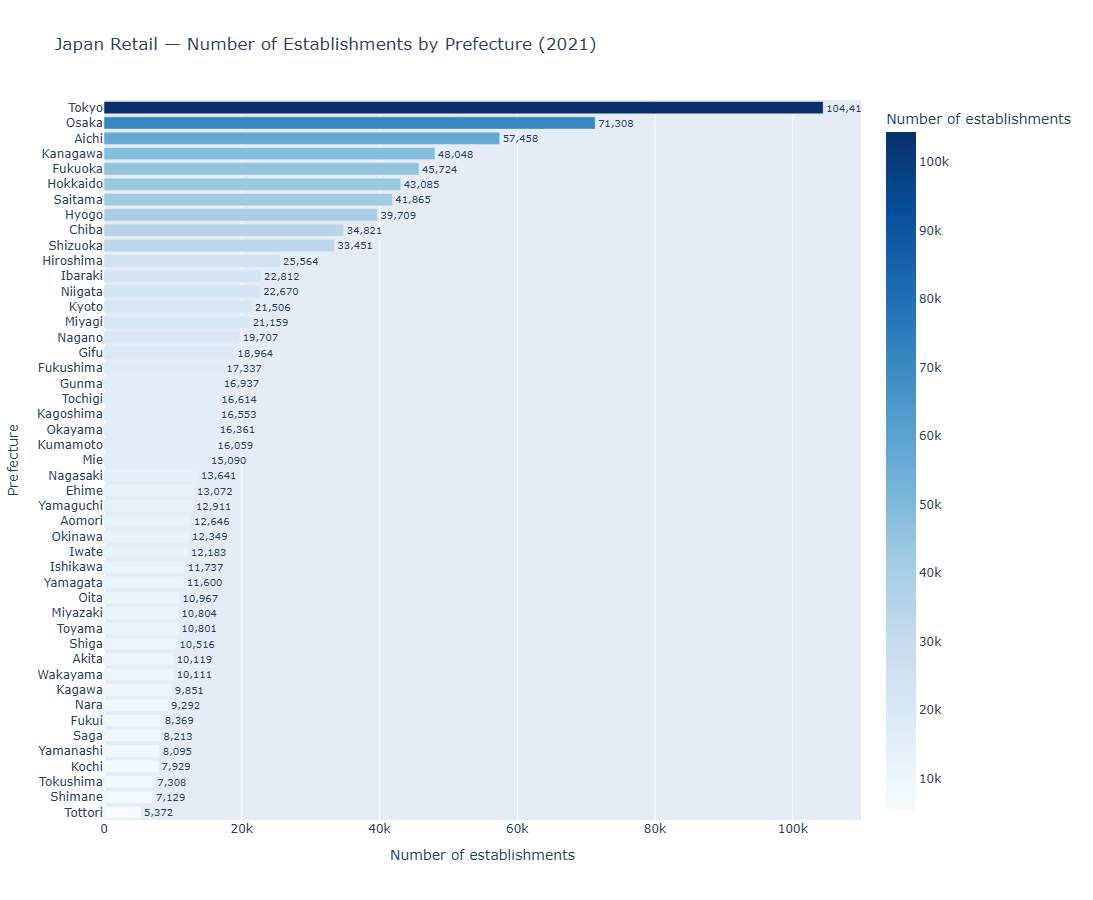

In [19]:
# Total retail establishments per prefecture (industry I = all retail)
estab = pref_totals[
    (pref_totals["industry_code"] == "I") &
    (pref_totals["unit"] == "number of establishments")
].sort_values("value", ascending=True)

fig7 = px.bar(
    estab,
    x="value",
    y="pref_name",
    orientation="h",
    color="value",
    color_continuous_scale="Blues",
    text=estab["value"].apply(lambda x: f"{x:,.0f}"),
    title="Japan Retail — Number of Establishments by Prefecture (2021)",
    labels={"value":     "Number of establishments",
            "pref_name": "Prefecture"}
)
fig7.update_traces(textposition="outside")
fig7.update_layout(height=900, showlegend=False,
                   margin=dict(l=100, r=150))
fig7.show()

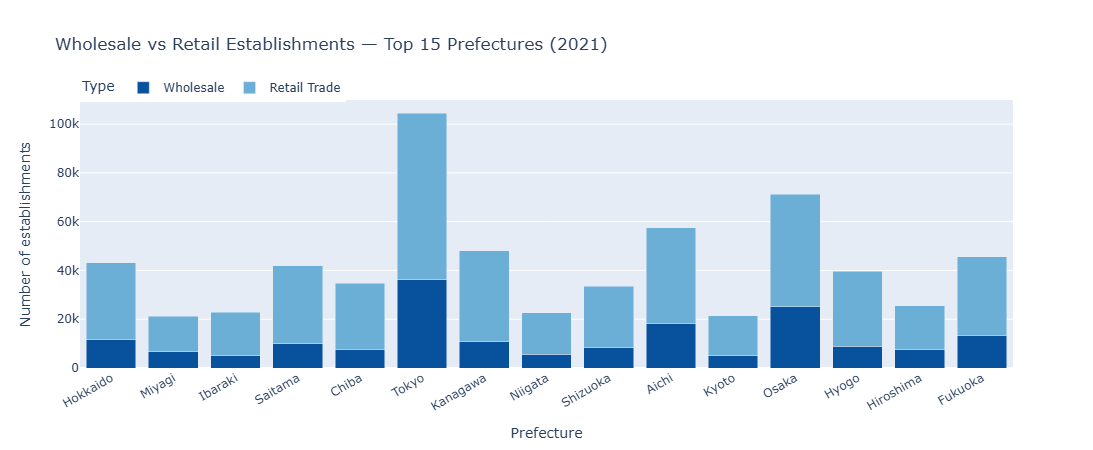

In [20]:
# Wholesale (I1) vs Retail (I2) by top 15 prefectures
wvsr_pref = pref_totals[
    (pref_totals["industry_code"].isin(["I1","I2"])) &
    (pref_totals["unit"] == "number of establishments")
].copy()

industry_label = {"I1": "Wholesale", "I2": "Retail Trade"}
wvsr_pref["trade_type"] = wvsr_pref["industry_code"].map(industry_label)

# Top 15 by total establishments
top15_pref = (pref_totals[
    (pref_totals["industry_code"] == "I") &
    (pref_totals["unit"] == "number of establishments")
].nlargest(15, "value")["pref_name"].tolist())

wvsr_top = wvsr_pref[wvsr_pref["pref_name"].isin(top15_pref)]

fig8 = px.bar(
    wvsr_top,
    x="pref_name",
    y="value",
    color="trade_type",
    barmode="stack",
    title="Wholesale vs Retail Establishments — Top 15 Prefectures (2021)",
    labels={"value":      "Number of establishments",
            "pref_name":  "Prefecture",
            "trade_type": "Type"},
    color_discrete_map={
        "Wholesale":    "#08519c",
        "Retail Trade": "#6baed6"
    }
)
fig8.update_layout(height=450,
    xaxis_tickangle=-30,
    legend=dict(orientation="h", y=1.1))
fig8.show()

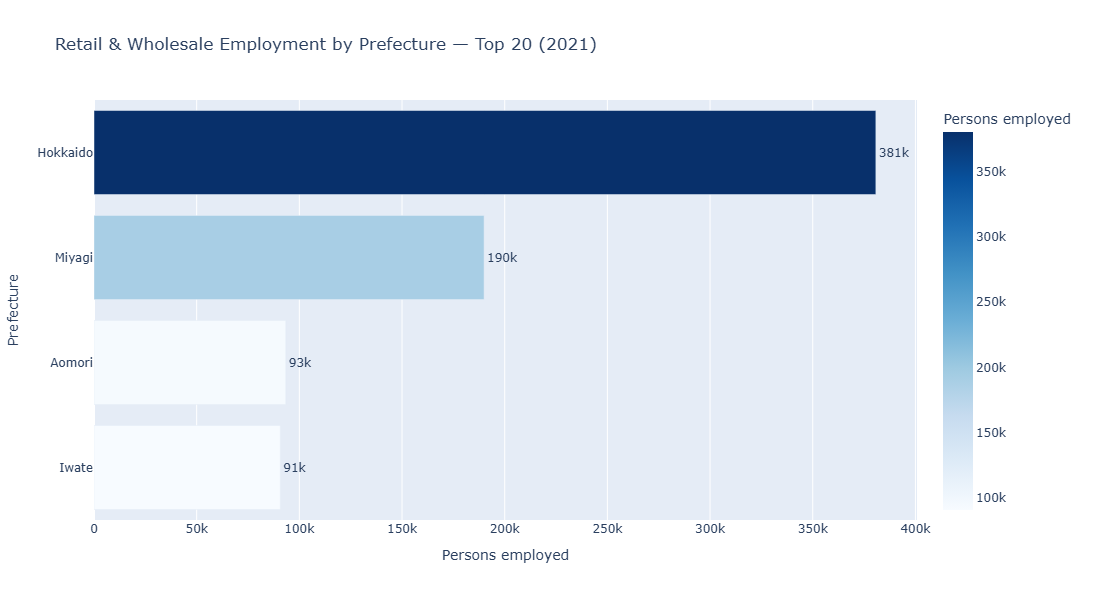

In [21]:
employment = pref_totals[
    (pref_totals["industry_code"] == "I") &
    (pref_totals["unit"] == "persons")
].sort_values("value", ascending=False).head(20)

fig9 = px.bar(
    employment.sort_values("value"),
    x="value",
    y="pref_name",
    orientation="h",
    color="value",
    color_continuous_scale="Blues",
    text=employment.sort_values("value")["value"].apply(
        lambda x: f"{x/1000:.0f}k"
    ),
    title="Retail & Wholesale Employment by Prefecture — Top 20 (2021)",
    labels={"value":     "Persons employed",
            "pref_name": "Prefecture"}
)
fig9.update_traces(textposition="outside")
fig9.update_layout(height=600, showlegend=False,
                   margin=dict(r=80))
fig9.show()

In [22]:
import os
os.makedirs("../docs/screenshots", exist_ok=True)

fig1.write_html("../docs/screenshots/11_cpi_trend.html")
fig2.write_html("../docs/screenshots/11_cpi_yoy.html")
fig3.write_html("../docs/screenshots/11_food_vs_all.html")
fig4.write_html("../docs/screenshots/11_retail_by_category.html")
fig5.write_html("../docs/screenshots/11_retail_yoy_growth.html")
fig6.write_html("../docs/screenshots/11_wholesale_vs_retail.html")
fig7.write_html("../docs/screenshots/11_estab_by_pref.html")
fig8.write_html("../docs/screenshots/11_wvsr_by_pref.html")
fig9.write_html("../docs/screenshots/11_employment_by_pref.html")

print("JAPAN RETAIL MARKET INTELLIGENCE SUMMARY")
print()
print("DATA SOURCES:")
print("  CPI     : e-Stat 2020-base CPI, monthly 2015–2026")
print("  Industry: Census of Commerce 2023+2024, wholesale/retail")
print("  Prefect : Census of Commerce 2021, all 47 prefectures")
print()

peak = cpi_all.loc[cpi_all["yoy_change"].idxmax()]
print("CPI FINDINGS:")
print(f"  Peak inflation : {peak['yoy_change']:.1f}% "
      f"({peak['date'].strftime('%b %Y')})")
print(f"  Post-2022 avg  : {post2022['yoy_change'].mean():.2f}% YoY")
print(f"  Food vs overall: Food CPI consistently above all-items")
print()

top_cat = retail_pivot.nlargest(1,"yoy_growth_pct")
bot_cat = retail_pivot.nsmallest(1,"yoy_growth_pct")
print("RETAIL INDUSTRY FINDINGS (2023→2024):")
print(f"  Fastest growing: {top_cat['category'].values[0]} "
      f"({top_cat['yoy_growth_pct'].values[0]}%)")
print(f"  Declining      : {bot_cat['category'].values[0]} "
      f"({bot_cat['yoy_growth_pct'].values[0]}%)")
print()

top_pref = estab.nlargest(3,"value")["pref_name"].tolist()
print("PREFECTURE FINDINGS:")
print(f"  Top 3 by establishments: {', '.join(top_pref)}")
print(f"  Total retail establishments nationwide: "
      f"{estab['value'].sum():,.0f}")
print()
print("BUSINESS IMPLICATIONS:")
print("  1. Post-COVID inflation drove food prices above 4% YoY in 2023")
print("  2. Nonstore (e-commerce) retail is the fastest growing segment")
print("  3. Tokyo, Osaka, Aichi dominate retail concentration")
print("  4. Rural prefectures declining in establishment count")
print("  5. Wholesale-to-retail ratio reveals supply chain structure")

JAPAN RETAIL MARKET INTELLIGENCE SUMMARY

DATA SOURCES:
  CPI     : e-Stat 2020-base CPI, monthly 2015–2026
  Industry: Census of Commerce 2023+2024, wholesale/retail
  Prefect : Census of Commerce 2021, all 47 prefectures

CPI FINDINGS:
  Peak inflation : 4.4% (Jan 2023)
  Post-2022 avg  : 2.86% YoY
  Food vs overall: Food CPI consistently above all-items

RETAIL INDUSTRY FINDINGS (2023→2024):
  Fastest growing: General Merchandise Retail (226.84%)
  Declining      : Miscellaneous Retail (-24.65%)

PREFECTURE FINDINGS:
  Top 3 by establishments: Tokyo, Osaka, Aichi
  Total retail establishments nationwide: 1,022,230

BUSINESS IMPLICATIONS:
  1. Post-COVID inflation drove food prices above 4% YoY in 2023
  2. Nonstore (e-commerce) retail is the fastest growing segment
  3. Tokyo, Osaka, Aichi dominate retail concentration
  4. Rural prefectures declining in establishment count
  5. Wholesale-to-retail ratio reveals supply chain structure


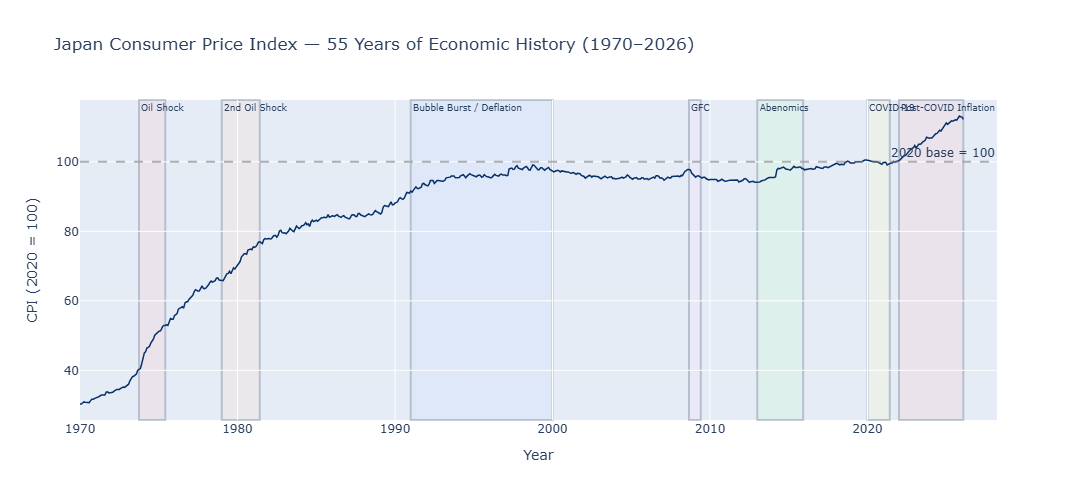

In [24]:
# All items CPI — full history 1970-2026
cpi_allitems = cpi[cpi["item_name"] == "All items"].sort_values("date").copy()
cpi_allitems["yoy_change"] = cpi_allitems["cpi_value"].pct_change(12) * 100

# Define Japan's major economic eras
eras = [
    ("1973-10-01", "1975-06-01", "#ffcccc", "Oil Shock"),
    ("1979-01-01", "1981-06-01", "#ffe0cc", "2nd Oil Shock"),
    ("1991-01-01", "2000-01-01", "#cce0ff", "Bubble Burst / Deflation"),
    ("2008-09-01", "2009-06-01", "#ffe0ff", "GFC"),
    ("2013-01-01", "2015-12-01", "#ccffcc", "Abenomics"),
    ("2020-01-01", "2021-06-01", "#ffffcc", "COVID-19"),
    ("2022-01-01", "2026-02-01", "#ffcccc", "Post-COVID Inflation"),
]

fig_hist = go.Figure()

# Shade eras first
for start, end, color, label in eras:
    fig_hist.add_vrect(
        x0=start, x1=end,
        fillcolor=color, opacity=0.25,
        annotation_text=label,
        annotation_position="top left",
        annotation_font_size=9,
        layer="below"
    )

# CPI line
fig_hist.add_trace(go.Scatter(
    x=cpi_allitems["date"],
    y=cpi_allitems["cpi_value"],
    mode="lines",
    line=dict(color="#08306b", width=1.5),
    name="CPI All items (2020=100)"
))

# 2020 base reference
fig_hist.add_hline(
    y=100, line_dash="dash",
    line_color="gray", opacity=0.6,
    annotation_text="2020 base = 100"
)

fig_hist.update_layout(
    title="Japan Consumer Price Index — 55 Years of Economic History (1970–2026)",
    xaxis_title="Year",
    yaxis_title="CPI (2020 = 100)",
    height=500,
    font=dict(size=12)
)
fig_hist.show()

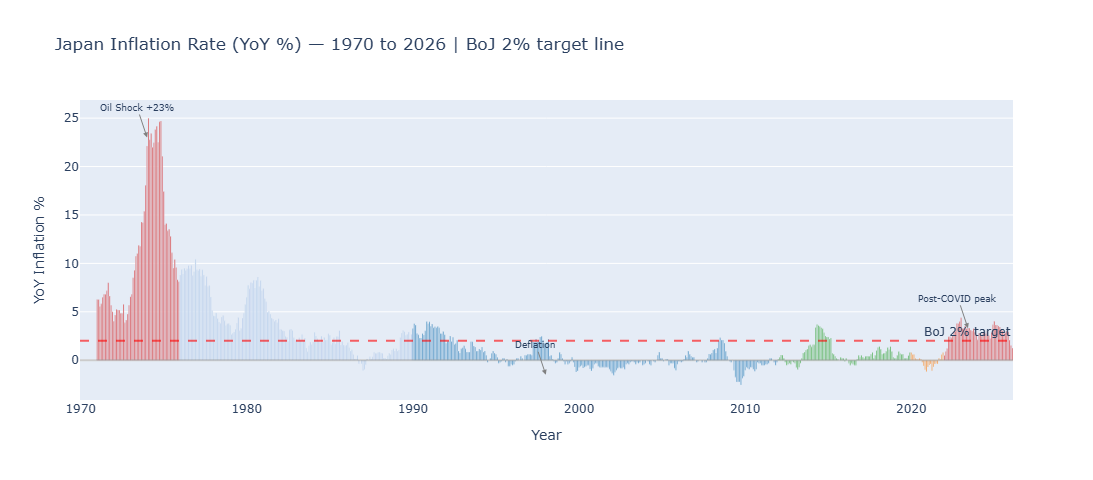

In [25]:
fig_yoy_hist = go.Figure()

# Colour bars by era
def get_era_color(date):
    if date < pd.Timestamp("1976-01-01"): return "#d62728"   # Oil shock
    elif date < pd.Timestamp("1990-01-01"): return "#aec7e8" # Stable growth
    elif date < pd.Timestamp("2012-01-01"): return "#1f77b4" # Deflation era
    elif date < pd.Timestamp("2020-01-01"): return "#2ca02c" # Abenomics
    elif date < pd.Timestamp("2022-01-01"): return "#ff7f0e" # COVID
    else: return "#d62728"                                    # Post-COVID surge

colors_hist = [get_era_color(d) for d in cpi_allitems["date"]]

fig_yoy_hist.add_trace(go.Bar(
    x=cpi_allitems["date"],
    y=cpi_allitems["yoy_change"],
    marker_color=colors_hist,
    name="YoY inflation %"
))

fig_yoy_hist.add_hline(
    y=2, line_dash="dash", line_color="red", opacity=0.6,
    annotation_text="BoJ 2% target"
)
fig_yoy_hist.add_hline(y=0, line_color="gray", opacity=0.4)

# Annotate key events
annotations = [
    ("1974-01-01", 23, "Oil Shock\n+23%"),
    ("1998-01-01", -1.5, "Deflation"),
    ("2023-06-01", 3.3, "Post-COVID\npeak"),
]
for x, y, text in annotations:
    fig_yoy_hist.add_annotation(
        x=x, y=y, text=text,
        showarrow=True, arrowhead=2,
        font=dict(size=9), arrowcolor="gray"
    )

fig_yoy_hist.update_layout(
    title="Japan Inflation Rate (YoY %) — 1970 to 2026 | BoJ 2% target line",
    xaxis_title="Year",
    yaxis_title="YoY Inflation %",
    height=480
)
fig_yoy_hist.show()

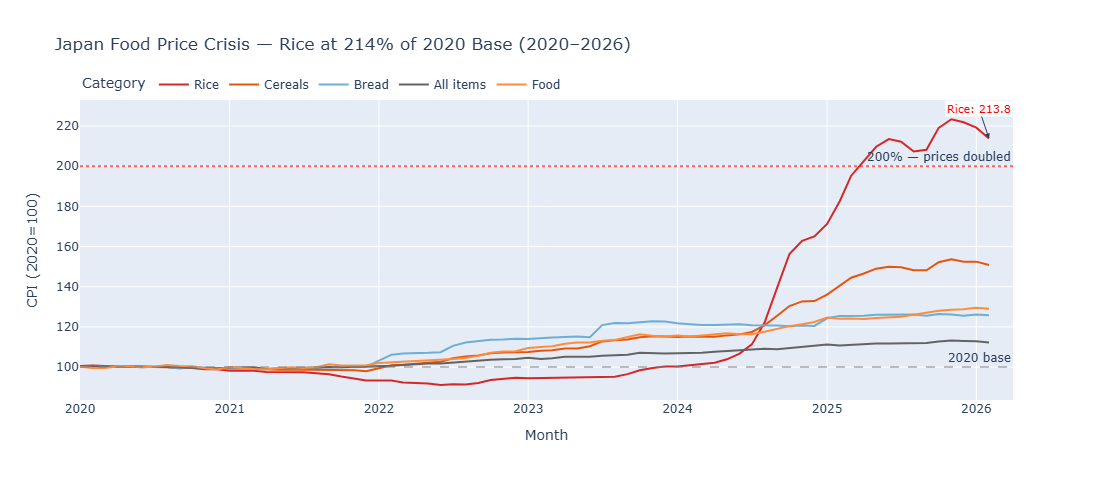

Rice CPI Feb 2026  : 213.8 (2020=100)
Bread CPI Feb 2026 : 125.8
Food CPI Feb 2026  : 129.0
All items Feb 2026 : 112.2


In [26]:
# Rice prices — the biggest Japan food story of 2025-2026
rice_items = ["All items", "Food", "Rice", "Bread", "Cereals"]
rice_df = cpi[
    (cpi["item_name"].isin(rice_items)) &
    (cpi["date"] >= "2020-01-01")
].sort_values("date")

fig_rice = px.line(
    rice_df,
    x="date",
    y="cpi_value",
    color="item_name",
    title="Japan Food Price Crisis — Rice at 214% of 2020 Base (2020–2026)",
    labels={"cpi_value": "CPI (2020=100)",
            "date":      "Month",
            "item_name": "Category"},
    color_discrete_map={
        "All items": "#636363",
        "Food":      "#fd8d3c",
        "Rice":      "#d62728",
        "Bread":     "#6baed6",
        "Cereals":   "#e6550d"
    }
)

fig_rice.add_hline(
    y=100, line_dash="dash",
    line_color="gray", opacity=0.5,
    annotation_text="2020 base"
)

fig_rice.add_hline(
    y=200, line_dash="dot",
    line_color="red", opacity=0.6,
    annotation_text="200% — prices doubled"
)

# Annotate latest rice value
latest_rice = rice_df[rice_df["item_name"] == "Rice"].iloc[-1]
fig_rice.add_annotation(
    x=latest_rice["date"],
    y=latest_rice["cpi_value"],
    text=f"Rice: {latest_rice['cpi_value']:.1f}",
    showarrow=True,
    arrowhead=2,
    font=dict(size=11, color="red"),
    bgcolor="white"
)

fig_rice.update_layout(height=480,
    legend=dict(orientation="h", y=1.1))
fig_rice.show()

print(f"Rice CPI Feb 2026  : {latest_rice['cpi_value']:.1f} (2020=100)")
print(f"Bread CPI Feb 2026 : {rice_df[rice_df['item_name']=='Bread'].iloc[-1]['cpi_value']:.1f}")
print(f"Food CPI Feb 2026  : {rice_df[rice_df['item_name']=='Food'].iloc[-1]['cpi_value']:.1f}")
print(f"All items Feb 2026 : {rice_df[rice_df['item_name']=='All items'].iloc[-1]['cpi_value']:.1f}")

JAPAN INFLATION — ERA COMPARISON
              Era            Period  Avg YoY %  Peak YoY %  Min YoY %  Months above 2%
        Oil Shock 1973-01 → 1975-12      15.54       25.00       6.57               36
   Bubble Economy 1987-01 → 1991-12       1.88        4.00      -1.07               33
    Deflation Era 1999-01 → 2012-12      -0.28        2.31      -2.56                3
        Abenomics 2013-01 → 2019-12       0.82        3.70      -0.95               12
     COVID Period 2020-01 → 2021-12      -0.13        0.81      -1.19                0
 Post-COVID Surge 2022-01 → 2024-12       2.84        4.39       0.50               33
2025-26 (Current) 2025-01 → 2026-02       2.92        4.02       1.26               12


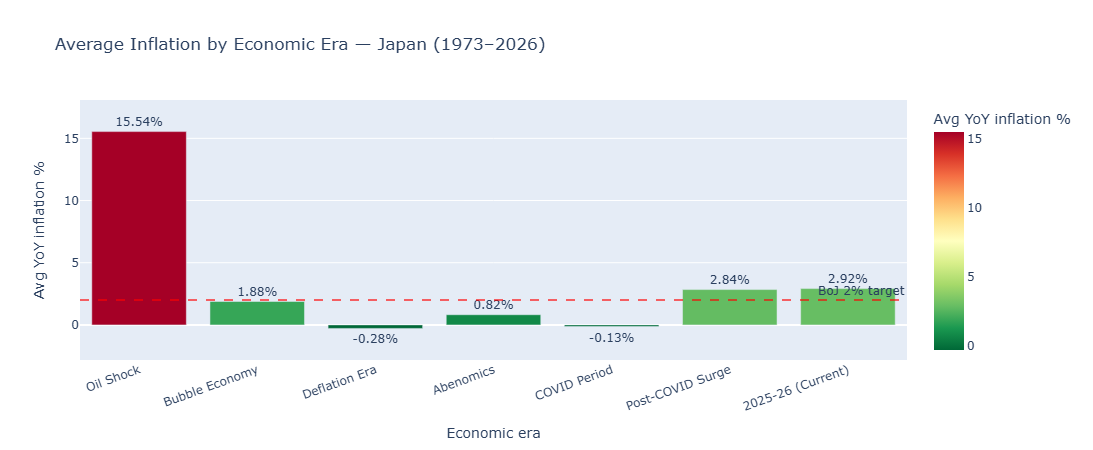

In [27]:
# Compare average inflation across eras
era_analysis = [
    ("Oil Shock",         "1973-01-01", "1975-12-01"),
    ("Bubble Economy",    "1987-01-01", "1991-12-01"),
    ("Deflation Era",     "1999-01-01", "2012-12-01"),
    ("Abenomics",         "2013-01-01", "2019-12-01"),
    ("COVID Period",      "2020-01-01", "2021-12-01"),
    ("Post-COVID Surge",  "2022-01-01", "2024-12-01"),
    ("2025-26 (Current)", "2025-01-01", "2026-02-01"),
]

era_stats = []
for era_name, start, end in era_analysis:
    subset = cpi_allitems[
        (cpi_allitems["date"] >= start) &
        (cpi_allitems["date"] <= end)
    ]
    if len(subset) > 0:
        era_stats.append({
            "Era":              era_name,
            "Period":           f"{start[:7]} → {end[:7]}",
            "Avg YoY %":        round(subset["yoy_change"].mean(), 2),
            "Peak YoY %":       round(subset["yoy_change"].max(), 2),
            "Min YoY %":        round(subset["yoy_change"].min(), 2),
            "Months above 2%":  int((subset["yoy_change"] > 2).sum()),
        })

era_df = pd.DataFrame(era_stats)
print("=" * 70)
print("JAPAN INFLATION — ERA COMPARISON")
print("=" * 70)
print(era_df.to_string(index=False))

fig_era = px.bar(
    era_df,
    x="Era",
    y="Avg YoY %",
    color="Avg YoY %",
    color_continuous_scale="RdYlGn_r",
    text=era_df["Avg YoY %"].astype(str) + "%",
    title="Average Inflation by Economic Era — Japan (1973–2026)",
    labels={"Avg YoY %": "Avg YoY inflation %",
            "Era":        "Economic era"}
)
fig_era.add_hline(
    y=2, line_dash="dash",
    line_color="red", opacity=0.6,
    annotation_text="BoJ 2% target"
)
fig_era.update_traces(textposition="outside")
fig_era.update_layout(
    height=450,
    xaxis_tickangle=-20,
    showlegend=False
)
fig_era.show()

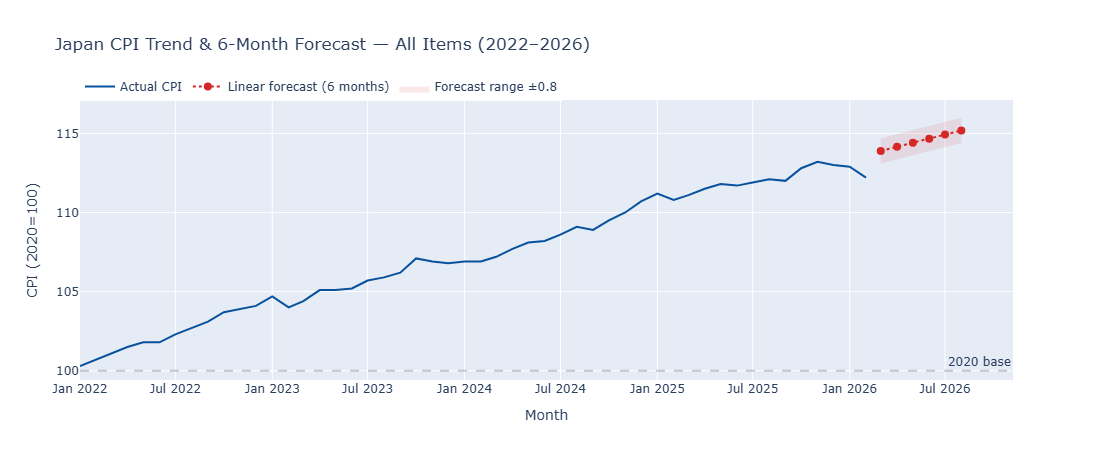

Current CPI (Feb 2026) : 112.2
Forecast Aug 2026      : 115.2
Trend direction        : Rising
Monthly change rate    : 0.260 CPI points/month


In [28]:
from sklearn.linear_model import LinearRegression

# Take last 24 months and forecast 6 more
recent = cpi_allitems[cpi_allitems["date"] >= "2024-01-01"].copy()
recent["t"] = range(len(recent))

X_train = recent[["t"]]
y_train = recent["cpi_value"]

lr = LinearRegression()
lr.fit(X_train, y_train)

# Forecast 6 months ahead
last_date = recent["date"].max()
future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=6, freq="MS"
)
future_t = range(len(recent), len(recent) + 6)
future_cpi = lr.predict(pd.DataFrame({"t": future_t}))

fig_fore = go.Figure()

# Historical
fig_fore.add_trace(go.Scatter(
    x=cpi_allitems[cpi_allitems["date"] >= "2022-01-01"]["date"],
    y=cpi_allitems[cpi_allitems["date"] >= "2022-01-01"]["cpi_value"],
    mode="lines",
    line=dict(color="#08519c", width=2),
    name="Actual CPI"
))

# Forecast
fig_fore.add_trace(go.Scatter(
    x=future_dates,
    y=future_cpi,
    mode="lines+markers",
    line=dict(color="#d62728", width=2, dash="dot"),
    marker=dict(size=8),
    name="Linear forecast (6 months)"
))

# Confidence band
fig_fore.add_trace(go.Scatter(
    x=list(future_dates) + list(future_dates[::-1]),
    y=list(future_cpi + 0.8) + list((future_cpi - 0.8)[::-1]),
    fill="toself",
    fillcolor="rgba(214,39,40,0.1)",
    line=dict(color="rgba(255,255,255,0)"),
    name="Forecast range ±0.8"
))

fig_fore.add_hline(
    y=100, line_dash="dash",
    line_color="gray", opacity=0.4,
    annotation_text="2020 base"
)

fig_fore.update_layout(
    title="Japan CPI Trend & 6-Month Forecast — All Items (2022–2026)",
    xaxis_title="Month",
    yaxis_title="CPI (2020=100)",
    height=460,
    legend=dict(orientation="h", y=1.1)
)
fig_fore.show()

print(f"Current CPI (Feb 2026) : {recent['cpi_value'].iloc[-1]:.1f}")
print(f"Forecast Aug 2026      : {future_cpi[-1]:.1f}")
print(f"Trend direction        : {'Rising' if lr.coef_[0] > 0 else 'Falling'}")
print(f"Monthly change rate    : {lr.coef_[0]:.3f} CPI points/month")

In [29]:
fig_hist.write_html("../docs/screenshots/11_cpi_55years.html")
fig_yoy_hist.write_html("../docs/screenshots/11_inflation_history.html")
fig_rice.write_html("../docs/screenshots/11_rice_crisis.html")
fig_era.write_html("../docs/screenshots/11_era_comparison.html")
fig_fore.write_html("../docs/screenshots/11_cpi_forecast.html")

print("Additional charts saved.")

Additional charts saved.


In [30]:
con.close()
print("Connection closed")

Connection closed
